# Monolayer γ-Graphyne

This tutorial focuses on electron transport in 2D γ-graphyne. It includes the calculation of electronic band energies on a k-point mesh, using the same input setup as the EPC calculation, followed by the calculation of transport properties.

We use analytic models based on parabolic and Kane-band (non-parabolic band) assumptions to calculate transport properties. We then compare the mobilities obtained from these analytic models with the numerical results. The comparison shows the effect of band non-parabolicity on the mobility.

DFTBephy includes an [analytical module](https://github.com/CoMeT4MatSci/dftbephy/blob/mrta/dftbephy/analytical.py), which provides tools for analytic transport models. The module can be used directly by importing it from the `dftbephy` package.

For the detailed information about the graphynes, please see our [paper](https://pubs.rsc.org/en/content/articlelanding/2025/nr/d5nr02989a). Our results for graphynes can be found on [Zenodo](https://zenodo.org/records/15113188).  

## Band Structure

The band energies can be calculated on the chosen k-mesh using `dftbephy epc` option.
The EPC block `EPC {}` is defined in `dftbephy_in.hsd` and can, for example, be specified as

```
     EPCs = {
        qpoints = Mesh {
            npoints = 100 100 1
            refinement = 1
        }
        kvec0 = 0.0 0.5 0.0     # M-point where the band edges lie
        bands = 21 26           
    }
```

One can use the `Bands.ipynb` notebook to visualize and analyze the results.  

**Bands.ipynb:**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import matplotlib.cm as cm  # Import colormap
import matplotlib.colors as mcolors

import h5py

In [2]:
basedir = './'

In [3]:
def read_epc2(fname):
    with h5py.File(fname, 'r') as f:
        mesh_qpoints = f['ph']['qpointsCart'][()]
        mesh_epskq = f['el']['eps_q_0'][()]
        eps_k = f['el']['eps_0'][()]
        energies = f['el']['energies'][()][:,1:5]     
    
    return eps_k, mesh_qpoints, mesh_epskq, energies

In [6]:
eps_k, mesh_qpoints, mesh_epskq, energies = read_epc2(basedir +'el-ph7x7/el-ph-Nq100-K-bandsel.hdf5')
    
qx = mesh_qpoints[:,0]
qy = mesh_qpoints[:,1]
a0 = 6.92               # lattice constant
q_unit = 2*np.pi/a0

# k-points
q = np.sqrt(qx**2 + qy**2)

In [7]:
# Energy Gap & Fermi Energy
Eg = (eps_k[3] - eps_k[2])
EF = (eps_k[3] + eps_k[2]) / 2    #Fermi energy is set to middle of the gap

In this example, `alpha`, non-parabolicity constant used in the Kane-band model, is obtained by fitting the band dispersion near the band edge.

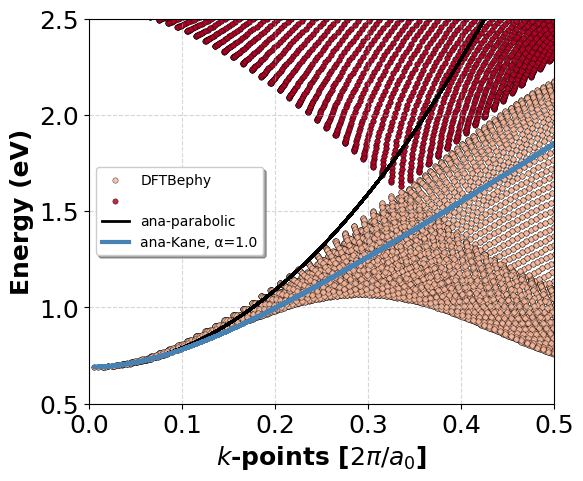

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

# Colormap for scatter plots
colors = ["#2E8B57", "#4682B4"] 
scatter_cmap = cm.coolwarm  #
norm = mcolors.Normalize(vmin=1, vmax=4) 

# Scatter plot DFTBephy
for lam in range(3, 5):  
    scatter_color = scatter_cmap(norm(lam)) 
    label = " " if lam == 4 else "DFTBephy" 
    ax.scatter(q, mesh_epskq[:, lam] - EF, color=scatter_color, s=15, alpha=0.85, edgecolors='black', linewidth=0.3, label=label)

# Analytical Parabolic-Band Dispersion
ax.plot(q, Eg/2 + ((qx)**2 + (qy)**2) * (q_unit)**2 * (10/(q_unit)**2), 'k-', linewidth=2, alpha=1,
       label=f"ana-parabolic")

# Analytical Kane-Band Dispersion
alpha_values = [1.0]       # non-parabolicity constant
kane2 = Eg/2 + np.sqrt((((qx)**2 + (qy)**2) * (q_unit)**2 * 
                        (10/(q_unit)**2/alpha_values[0])) + 1/(4*alpha_values[0]**2)) - 1/(2*alpha_values[0])

ax.plot(q, kane2, color="#4682B4", linewidth=3, 
        label=f"ana-Kane, α={alpha_values[0]}")

# Axis
ax.set_ylim(0.5, 2.5)
ax.set_xlim(0.0, 0.5)
ax.grid(True, linestyle="--", alpha=0.5)  # Add a light grid

ax.tick_params(axis='both', which='major', labelsize=18)  

ax.set_ylabel("Energy (eV)", fontsize=18, fontweight='bold')
ax.set_xlabel(r"$k$-points [$2\pi/a_0$]", fontsize=18, fontweight='bold') 

# Legend 
ax.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)

plt.show()

The analytical Kane-band model shows better agreement with the conduction band up to energies of approximately 0.6 eV.

## Transport Properties

Mobility calculations are performed with the standard DFTBephy workflow: 
the numerical electrical conductivities and the corresponding numerical carrier densities are calculated first. Then the mobilities are obtained in  post-processing step using the relation:

$$
\mu = \frac{\sigma}{n e}
$$

where $\sigma$ is the electrical conductivity, $n$ is the carrier density, and $e$ is the elementary charge. 

The Conductivities block `Conductivities= (method) {}` in `dftbephy_in.hsd` can be specified as

```
    Conductivities = SERTA {
        kpoints = Mesh {
            npoints = 250 250 1
            shift = 0.0 0.5 0.0
            refinement = 1
        }
        qpoints = Mesh {
            npoints = 100 100 1
            refinement = 2
        }
        Efermi [eV] = -4.805057
        bands = 21 26
        # mu is relativ to Efermi        
        mu [eV] = Range { 0.58890955 0.88890955 30 }           
        temperature [eV] = 0.02585

        sigma [eV] = 0.003
        # Ecut is relativ to Efermi 
        Ecut [eV] = 1.0
        SpinDegeneracy = 2
    }
```

The calculation is run with `dftbephy-mpi.py mobility`, either directly or through `mpirun` for parallel execution:

```
mpirun -np 4 python dftbephy-mpi.py mobility
```

Analysis can be done with the provided `Transport.ipynb`notebook:

**Transport.ipynb:**

In [9]:
import os

import json
import h5py

import numpy as np
from scipy.integrate import quad

import matplotlib
import matplotlib.pyplot as plt

from dftbephy.analytical import *                        # importing the analytical module

# Define a function to format tick labels
def format_ticks(value, pos):
    return f'{value:.2f}'  # Format to one decimal place

In [10]:
basedir = './'

### Reading the DFTBephy results

In [15]:
with open(basedir+'el-ph7x7/transport-mpi-serta.json') as jfile:
    data = json.load(jfile)      
data = json.loads(data)  
conductivities = np.array(data['conductivities'])
conductivities0 = np.array(data['conductivities0'])
densities = np.array(data['densities'])
own_mus = np.array(data['mus'])
own_EF = np.array(data['EF'])
cell_area = data['cell_area']
own_kBT = data['kBTs'][0]

## Analytical expressions 
Here, we use the analytical expressions for electron densities and conductivities defined in the [analytical module](https://github.com/CoMeT4MatSci/dftbephy/blob/mrta/dftbephy/analytical.py). These expressions are written as energy-dependent integrals and use the band dispersion from either the parabolic-band or Kane-band model.

A few material-specific parameters are required:

- `meff`: Effective mass, obtained from the curvature of the band at the band edge, including the $\hbar^2$ factor.
- `Eg`: Band gap in eV.
- `alpha`: Non-parabolicity constant.
- `gv`: Valley degeneracy, here 3 for the M-point.
- `gs`: Spin degeneracy.

In [16]:
meff = 0.24*0.136                                     # includes hbar^2 -> (d^2E/dk^2)^-1
Eg = 1.3799770873333674                               # eV

# non-parabolicity constant
alpha = 1

gv = 3                                                # Valley degeneracy for M-point
gs = 2                                                # Spin degeneracy

dTaudEps = 4.5/0.4                                    # Picosecond / eV

# Constants from analytical module
ElementaryCharge = Constants.ELEMENTARY_CHARGE_Aps    # [Ampere * picosecond]
qe_SI = Constants.qe_SI                               # Electron Charge [C]
Boltzmann = Constants.BOLTZMANN_eV

### Numerical integration
The charge densities and electrical conductivities are obtained via numerical integration:

In [17]:
limit = 5

para_c = Parabolic2D(gv=gv, gs=gs, meff=meff, band_type=Band.CONDUCTION, eps_edge=Eg/2)

ana_densities = np.array([
    quad(para_c.density, 0, limit, args=(mu, own_kBT), points=[0, mu])[0]
    for mu in (own_mus - own_EF)
])

ana_conductivities = np.array([
    quad(para_c.conductivity_crta, -limit, limit, args=(mu, own_kBT), points=[0, mu])[0]
    for mu in (own_mus - own_EF)
])

kane_c = Kane2D(gv=gv, gs=gs, meff=meff, alpha=alpha, band_type=Band.CONDUCTION, eps_edge=Eg/2)

ana_densities_np = np.array([
    quad(kane_c.density, 0, limit, args=(mu, own_kBT), points=[0, mu])[0]
    for mu in (own_mus - own_EF)
])

ana_conductivities_np = np.array([
    quad(kane_c.conductivity_crta, -limit, limit, args=(mu, own_kBT), points=[0, mu])[0]
    for mu in (own_mus - own_EF)
])

For holes, the same analytical framework is used as for electrons, but the band edge and integration limits are changed for the valence band. 
For holes, `band_type=Band.VALENCE` selects the valence-band formulation in `analytical` module, and `eps_edge=-Eg/2` sets the band edge at the valence-band maximum. The density integral is then evaluated over the valence-band energy range, up to `-limit`. For example:

In [18]:
para_v = Parabolic2D(gv=gv, gs=gs, meff=meff, band_type=Band.VALENCE, eps_edge=-Eg/2)

ana_densities = np.array([
    quad(para_v.density, 0, -limit, args=(mu, own_kBT), points=[0, mu])[0]
    for mu in (own_mus - own_EF)
])

ana_conductivities = np.array([
    quad(para_v.conductivity_crta, -limit, limit, args=(mu, own_kBT), points=[0, mu])[0]
    for mu in (own_mus - own_EF)
])

### Mobility

Here, the mobility obtained from the SERTA calculation ($\mu_{\mathrm{SERTA}}$) is used as a reference. The mobilities from the CRTA and analytical models are compared to this reference by taking the ratio of their maximum values. The in-plane trace of the conductivity tensor, $\sigma = \sigma_{xx} + \sigma_{yy}$ is considered. 

In [50]:
# dftbephy 
serta = (conductivities[:, 0, 0] + conductivities[:, 1, 1]) / np.abs(densities)
crta  = (conductivities0[:, 0, 0] + conductivities0[:, 1, 1]) / np.abs(densities)
# analytical
ana_para = 1e-8 * ana_conductivities / (ElementaryCharge * np.abs(ana_densities))
ana_kane = 1e-8 * ana_conductivities_np / (ElementaryCharge * np.abs(ana_densities_np))

# ratios
tau_serta_crta = np.max(serta) / np.max(crta)
tau_serta_ana = np.max(serta) / np.max(ana_para)
tau_serta_ana_np = np.max(serta) / np.max(ana_kane)

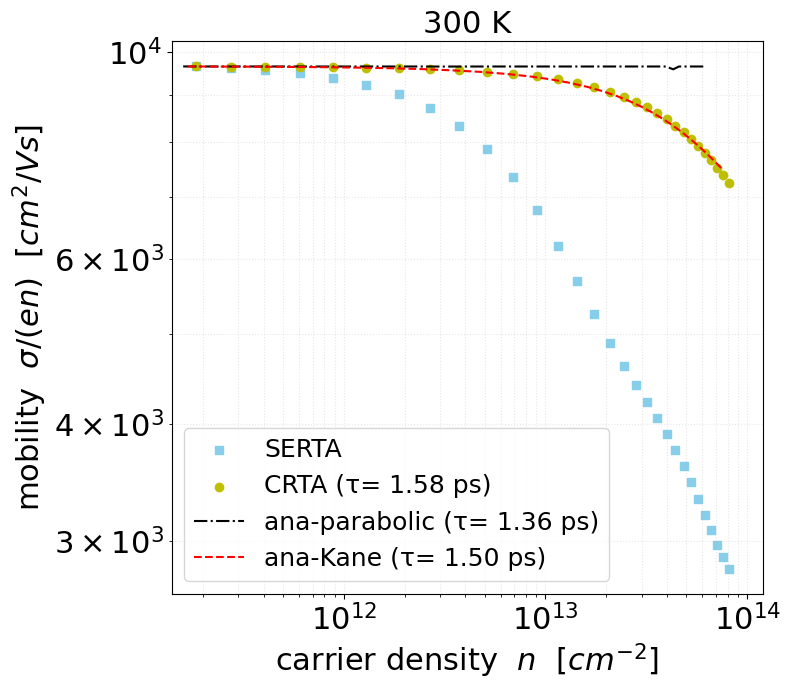

In [51]:
FontSize = 22

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# mobilities
ax.scatter(np.abs(densities * 1e16), 
           1e4*(conductivities[:,0,0]+conductivities[:,1,1])/(2*np.abs(densities)), 
           color='skyblue', label=r'SERTA', marker='s')

ax.scatter(np.abs(densities * 1e16), 
           taus_serta_crta_T[0] *1e4*(conductivities0[:,0,0]+conductivities0[:,1,1])/(2*np.abs(densities)), 
           color="y", label=f'CRTA (τ= {taus_serta_crta_T[0]:.2f} ps)')

ax.plot(np.abs(ana_densities * 1e16), 
        taus_serta_ana_T[0] *1e4* 1e-8 *ana_conductivities / (ElementaryCharge*2*np.abs(ana_densities)), 
        'k-.', label=f'ana-parabolic (τ= {taus_serta_ana_T[0]:.2f} ps)')

ax.plot(np.abs(ana_densities_np * 1e16), 
        taus_serta_ana_np_T[0] *1e4* 1e-8 *ana_conductivities_np / (ElementaryCharge*2*np.abs(ana_densities_np)), 
        'r--', label=f'ana-Kane (τ= {taus_serta_ana_np_T[0]:.2f} ps)')


ax.set_xscale('log')
ax.set_yscale('log')
    
ax.set_xlabel(r'carrier density  $n$  [$cm^{-2}$]', fontsize=FontSize)  
ax.set_ylabel(r'mobility  $\sigma/(e n)$  [$cm^{2}/V s$]', fontsize=FontSize)

ax.set_xlim((1.4e11, 1.2e14))
ax.legend(loc='lower left',fontsize=FontSize-4)

ax.set_title(f'{round(own_kBT / Boltzmann )} K', fontsize=FontSize)
ax.tick_params(axis='both', which='major', labelsize=FontSize)
matplotlib.rc('ytick', labelsize=FontSize) 
ax.grid(True, which="both", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()  

The SERTA approach provides the most detailed description because it uses the full electronic band dispersion together with explicitly calculated energy-dependent scattering rates.

In simplified models for 2D materials, such as deformation-potential models, the band is often assumed to be parabolic and the relaxation time is taken as constant. For a 2D parabolic band, the density of states (DOS) is constant. As a result, the analytical parabolic model predicts a mobility that is independent of carrier concentration, as seen in the analytical parabolic (`ana-parabolic`) result. 

However, mobility is sensitive to both the band shape and the energy dependence of the relaxation time. The analytical Kane-band model (`ana-Kane`) includes energy-dependent DOS and gives better agreement with the numerical CRTA mobilities from DFTBephy.
